# Torch 기반 장바구니 연관규칙 분석 실습

원본 흐름은 다음과 같습니다.

CSV 거래 데이터를 읽어서 거래 리스트 생성

one-hot 행렬의 평균으로 아이템 지지도 계산

matplotlib 막대그래프 출력

거래-아이템 희소행렬 시각화

torch 텐서 연산으로 후보 itemset 지지도 계산 후 규칙 생성

pandas DataFrame으로 규칙 확인 및 정렬

In [1]:
# ============================================================
# 1. Google Colab 실행 환경 확인
# ============================================================

# sys는 현재 파이썬 실행 환경 정보를 확인할 때 사용하는 기본 모듈입니다.
import sys

# os는 파일 경로 확인, 폴더 생성, 파일 존재 여부 확인 등에 사용하는 기본 모듈입니다.
import os

# itertools는 여러 아이템 조합을 만들 때 사용하는 표준 라이브러리입니다.
# 예: 우유, 빵, 버터 중 2개씩 묶는 모든 조합 생성
from itertools import combinations

# urllib.request는 인터넷 URL에서 파일을 내려받을 때 사용하는 표준 라이브러리입니다.
import urllib.request

# pandas는 표 형태의 데이터를 다루기 위한 대표적인 라이브러리입니다.
import pandas as pd

# numpy는 수치 계산을 위한 라이브러리이며, 데이터 변환 보조 용도로 사용합니다.
import numpy as np

# torch는 PyTorch 라이브러리이며, 텐서 기반 수치 연산에 사용합니다.
import torch

# matplotlib.pyplot은 그래프를 그릴 때 사용하는 라이브러리입니다.
import matplotlib.pyplot as plt

# 현재 파이썬 버전을 출력하여 Colab 환경을 확인합니다.
print("Python version:", sys.version)

# 현재 설치된 PyTorch 버전을 출력합니다.
print("PyTorch version:", torch.__version__)

# GPU 사용 가능 여부를 확인합니다.
# 이 실습은 데이터가 작아서 CPU만으로도 충분하지만, Colab 환경 점검용으로 출력합니다.
print("CUDA available:", torch.cuda.is_available())

Python version: 3.11.0rc1 (main, Aug 12 2022, 10:02:14) [GCC 11.2.0]
PyTorch version: 2.7.0+cu118
CUDA available: True


In [2]:
# ============================================================
# 2. 데이터 파일 준비
# ============================================================

# 실습에서 사용할 CSV 파일 경로를 지정합니다.
DATA_PATH = "../data/shop_groceries.csv"

# 공개 예제 grocery 데이터 URL입니다.
# 각 행은 하나의 장바구니 거래이며, 쉼표로 구매 물품들이 구분되어 있습니다.
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"

# 파일이 이미 존재하는지 확인합니다.
if not os.path.exists(DATA_PATH):
    # 파일이 없으면 공개 URL에서 다운로드합니다.
    print("CSV 파일이 없어 공개 grocery 데이터를 다운로드합니다.")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
else:
    # 파일이 있으면 기존 파일을 그대로 사용합니다.
    print("기존 CSV 파일을 사용합니다:", DATA_PATH)

# 준비된 파일 경로를 출력합니다.
print("데이터 파일 경로:", DATA_PATH)

기존 CSV 파일을 사용합니다: ../data/shop_groceries.csv
데이터 파일 경로: ../data/shop_groceries.csv


In [3]:
# ============================================================
# 3. 거래 데이터 읽기
# ============================================================

# transactions 리스트는 전체 거래 데이터를 저장합니다.
# 각 원소는 한 번의 장보기에서 구매한 아이템 이름들의 리스트입니다.
transactions = []

# CSV 파일을 한 줄씩 직접 읽습니다.
# grocery 데이터는 일반적인 표 형태가 아니라, 한 줄이 하나의 거래를 의미합니다.
with open(DATA_PATH, "r", encoding="utf-8") as f:
    # 파일의 모든 줄을 반복합니다.
    for line in f:
        # strip()은 줄 끝의 줄바꿈 문자와 양끝 공백을 제거합니다.
        line = line.strip()

        # 빈 줄은 거래 데이터가 아니므로 건너뜁니다.
        if line == "":
            continue

        # split(",")은 쉼표 기준으로 아이템 이름을 분리합니다.
        # 예: "milk,bread" -> ["milk", "bread"]
        items = line.split(",")

        # 각 아이템 이름에서 양쪽 공백을 제거하고, 빈 문자열은 제외합니다.
        items = [item.strip() for item in items if item.strip() != ""]

        # 한 거래 안에서 같은 아이템이 중복될 수 있으므로 set으로 중복 제거 후 다시 list로 바꿉니다.
        items = list(set(items))

        # 정리된 거래를 전체 transactions 리스트에 추가합니다.
        transactions.append(items)

# 전체 거래 수를 계산합니다.
num_transactions = len(transactions)

# 전체 아이템 목록을 만들기 위해 모든 거래의 아이템을 하나의 set에 모읍니다.
all_items = sorted(set(item for transaction in transactions for item in transaction))

# 전체 고유 아이템 수를 계산합니다.
num_items = len(all_items)

# 거래 수와 아이템 수를 출력합니다.
print("전체 거래 수:", num_transactions)
print("전체 고유 아이템 수:", num_items)

# 처음 5개 거래를 확인합니다.
print("처음 5개 거래:")
for i, transaction in enumerate(transactions[:5], start=1):
    print(f"거래 {i}:", transaction)

전체 거래 수: 9835
전체 고유 아이템 수: 169
처음 5개 거래:
거래 1: ['citrus fruit', 'margarine', 'ready soups', 'semi-finished bread']
거래 2: ['yogurt', 'tropical fruit', 'coffee']
거래 3: ['whole milk']
거래 4: ['yogurt', 'meat spreads', 'pip fruit', 'cream cheese']
거래 5: ['long life bakery product', 'whole milk', 'condensed milk', 'other vegetables']


In [4]:
# ============================================================
# 4. 거래 데이터를 one-hot 희소 행렬 형태로 변환
# ============================================================

# item_to_idx는 아이템 이름을 열 번호로 바꾸기 위한 딕셔너리입니다.
# 예: {'whole milk': 0, 'yogurt': 1, ...}
item_to_idx = {item: idx for idx, item in enumerate(all_items)}

# idx_to_item은 열 번호를 다시 아이템 이름으로 바꾸기 위한 딕셔너리입니다.
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

# torch.zeros()로 거래 수 x 아이템 수 크기의 행렬을 생성합니다.
# 값이 0이면 해당 거래에서 그 아이템을 사지 않았다는 뜻입니다.
# 값이 1이면 해당 거래에서 그 아이템을 샀다는 뜻입니다.
X = torch.zeros((num_transactions, num_items), dtype=torch.float32)

# 각 거래를 순회하면서 구매한 아이템 위치에 1을 표시합니다.
for row_idx, transaction in enumerate(transactions):
    # 현재 거래 안의 각 아이템을 반복합니다.
    for item in transaction:
        # 아이템 이름을 열 번호로 변환합니다.
        col_idx = item_to_idx[item]

        # 해당 거래(row_idx)에서 해당 아이템(col_idx)을 구매했으므로 1로 표시합니다.
        X[row_idx, col_idx] = 1.0

# 생성된 one-hot 행렬의 크기를 확인합니다.
print("one-hot 행렬 크기:", X.shape)

# 처음 5개 거래와 처음 10개 아이템 열만 잘라서 확인합니다.
print("처음 5개 거래 x 처음 10개 아이템 행렬:")
print(X[:5, :10])

# 처음 10개 아이템 이름을 출력합니다.
print("처음 10개 아이템 이름:")
print(all_items[:10])

one-hot 행렬 크기: torch.Size([9835, 169])
처음 5개 거래 x 처음 10개 아이템 행렬:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
처음 10개 아이템 이름:
['Instant food products', 'UHT-milk', 'abrasive cleaner', 'artif. sweetener', 'baby cosmetics', 'baby food', 'bags', 'baking powder', 'bathroom cleaner', 'beef']


In [5]:
# ============================================================
# 5. 아이템 빈도와 지지도 계산
# ============================================================

# 지지도(support)는 전체 거래 중 특정 아이템이 등장한 거래의 비율입니다.
# 예: 전체 100건 중 우유가 25건이면 우유의 support는 25 / 100 = 0.25입니다.

# X.mean(dim=0)은 각 열의 평균을 계산합니다.
# one-hot 값이 0 또는 1이므로 평균은 곧 각 아이템의 거래 비율, 즉 지지도입니다.
item_support_tensor = X.mean(dim=0)

# torch 텐서를 pandas DataFrame으로 변환하기 위해 numpy 배열로 바꿉니다.
item_support = item_support_tensor.numpy()

# 아이템별 지지도 표를 만듭니다.
item_freq_df = pd.DataFrame({
    "item": all_items,
    "support": item_support,
    "count": (item_support_tensor * num_transactions).to(torch.int64).numpy()
})

# 지지도 기준으로 내림차순 정렬합니다.
item_freq_df = item_freq_df.sort_values("support", ascending=False).reset_index(drop=True)

# 상위 10개 아이템을 출력합니다.
item_freq_df.head(10)

,item,support,count
0,whole milk,0.255516,2513
1,other vegetables,0.193493,1902
2,rolls/buns,0.183935,1809
3,soda,0.174377,1714
4,yogurt,0.139502,1372
5,bottled water,0.110524,1087
6,root vegetables,0.108998,1072
7,tropical fruit,0.104931,1032
8,shopping bags,0.098526,969
9,sausage,0.093950,923


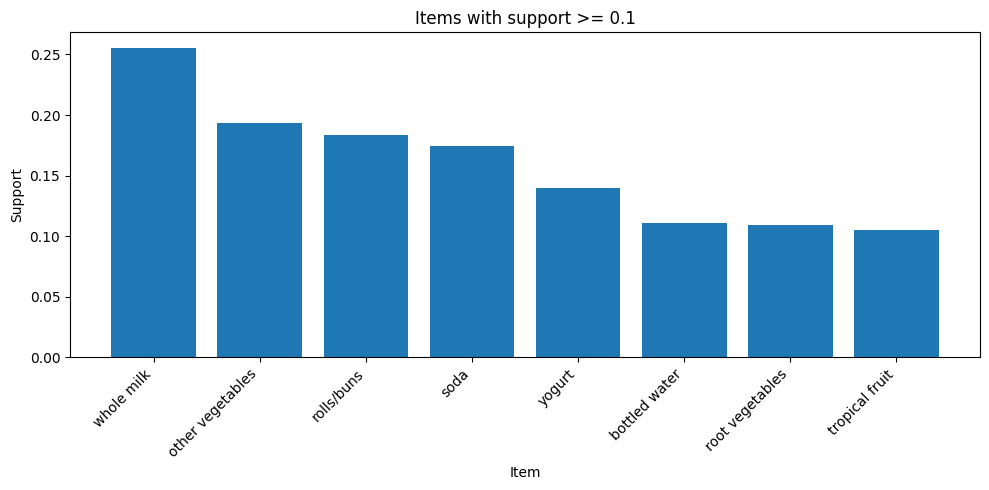

In [6]:
# ============================================================
# 6. 지지도 0.1 이상 아이템 시각화
# ============================================================

# support가 0.1 이상인 아이템만 선택합니다.
support_01_df = item_freq_df[item_freq_df["support"] >= 0.1]

# 그래프 크기를 지정합니다.
plt.figure(figsize=(10, 5))

# 막대그래프를 그립니다.
# x축은 아이템 이름, y축은 지지도입니다.
plt.bar(support_01_df["item"], support_01_df["support"])

# x축 라벨을 45도 회전시켜 긴 아이템 이름이 겹치지 않게 합니다.
plt.xticks(rotation=45, ha="right")

# 그래프 제목을 지정합니다.
plt.title("Items with support >= 0.1")

# x축 이름을 지정합니다.
plt.xlabel("Item")

# y축 이름을 지정합니다.
plt.ylabel("Support")

# 그래프 요소가 화면에서 잘리지 않도록 자동 정렬합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()

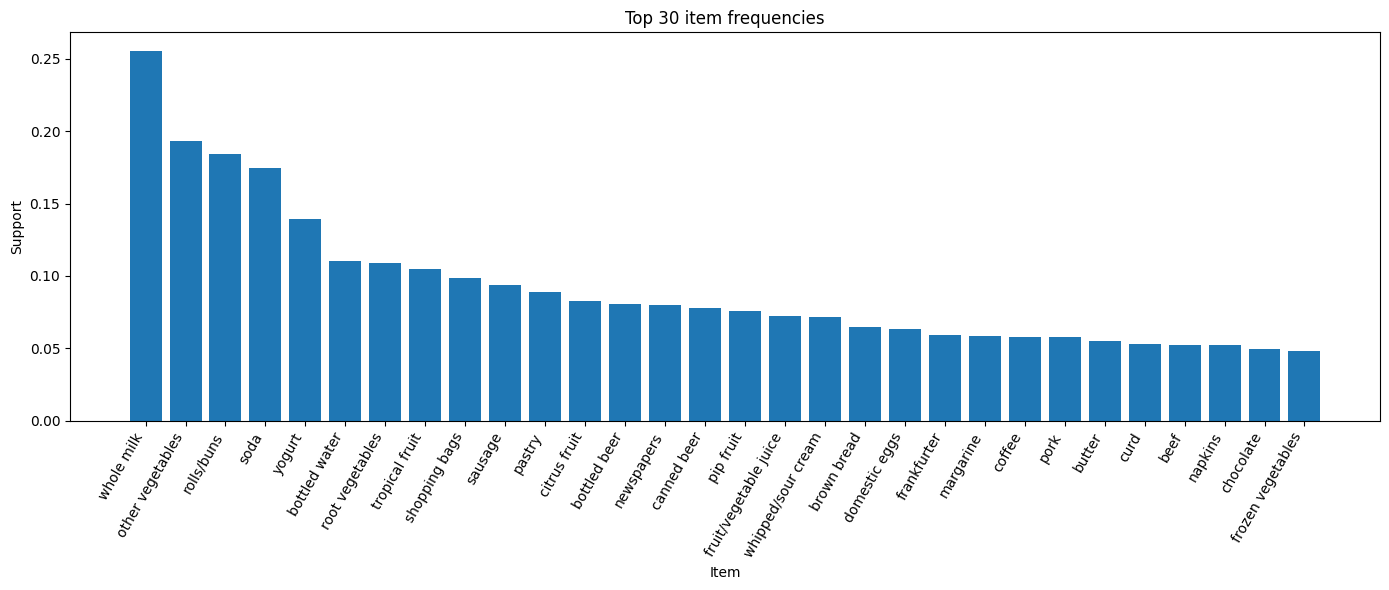

In [7]:
# ============================================================
# 7. 상위 30개 아이템 빈도 시각화
# ============================================================

# 지지도 상위 30개 아이템만 선택합니다.
top30_df = item_freq_df.head(30)

# 그래프 크기를 지정합니다.
plt.figure(figsize=(14, 6))

# 상위 30개 아이템의 지지도를 막대그래프로 출력합니다.
plt.bar(top30_df["item"], top30_df["support"])

# x축 라벨을 회전시켜 가독성을 높입니다.
plt.xticks(rotation=60, ha="right")

# 그래프 제목을 지정합니다.
plt.title("Top 30 item frequencies")

# x축 이름을 지정합니다.
plt.xlabel("Item")

# y축 이름을 지정합니다.
plt.ylabel("Support")

# 그래프 여백을 자동 조정합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()

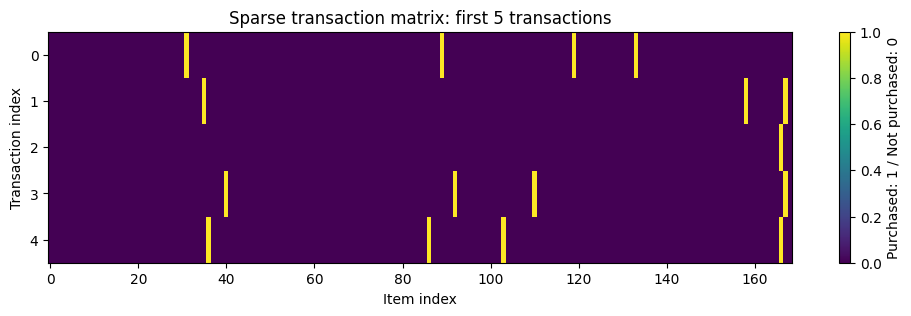

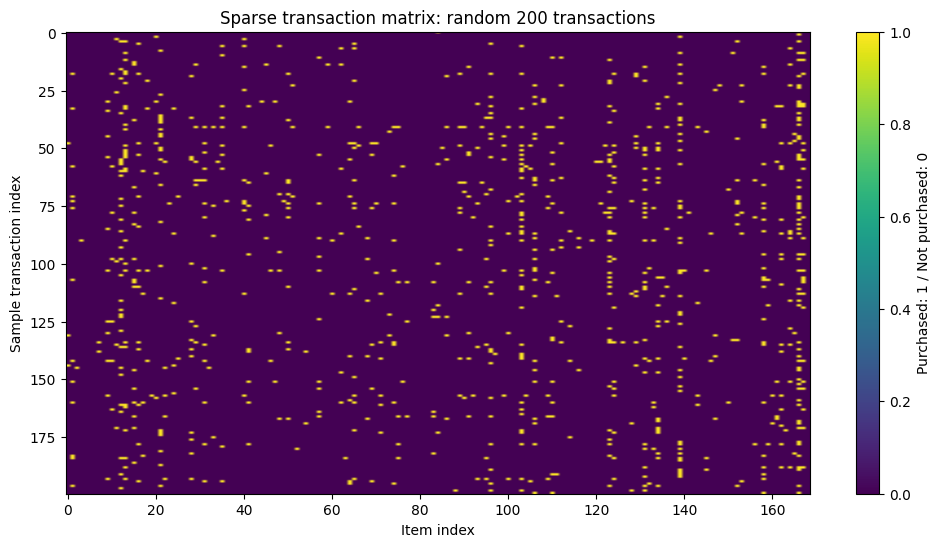

In [8]:
# ============================================================
# 8. 거래-아이템 희소 행렬 시각화
# ============================================================

# 처음 5개 거래의 one-hot 행렬을 이미지로 표시합니다.
plt.figure(figsize=(12, 3))

# imshow()는 행렬 값을 색으로 표시합니다.
# 1은 구매한 아이템, 0은 구매하지 않은 아이템을 의미합니다.
plt.imshow(X[:5].numpy(), aspect="auto")

# 그래프 제목을 지정합니다.
plt.title("Sparse transaction matrix: first 5 transactions")

# x축은 아이템 열 번호입니다.
plt.xlabel("Item index")

# y축은 거래 번호입니다.
plt.ylabel("Transaction index")

# 색상 막대를 표시합니다.
plt.colorbar(label="Purchased: 1 / Not purchased: 0")

# 그래프를 출력합니다.
plt.show()

# 200개 거래를 무작위로 뽑기 위해 난수 시드를 고정합니다.
torch.manual_seed(42)

# 전체 거래 번호 중 200개를 무작위로 선택합니다.
sample_indices = torch.randperm(num_transactions)[:200]

# 선택된 200개 거래의 one-hot 행렬을 이미지로 표시합니다.
plt.figure(figsize=(12, 6))

# 200개 거래와 전체 아이템 열의 희소 행렬을 시각화합니다.
plt.imshow(X[sample_indices].numpy(), aspect="auto")

# 그래프 제목을 지정합니다.
plt.title("Sparse transaction matrix: random 200 transactions")

# x축은 아이템 열 번호입니다.
plt.xlabel("Item index")

# y축은 무작위 샘플 거래 번호입니다.
plt.ylabel("Sample transaction index")

# 색상 막대를 표시합니다.
plt.colorbar(label="Purchased: 1 / Not purchased: 0")

# 그래프를 출력합니다.
plt.show()

In [9]:
# ============================================================
# 9. itemset 지지도 계산 함수 정의
# ============================================================

# 이 함수는 특정 아이템 조합이 전체 거래에서 얼마나 자주 함께 등장하는지 계산합니다.
# 예: ['whole milk', 'yogurt']가 전체 거래 중 몇 %에서 함께 등장하는지 계산합니다.
def calculate_itemset_support(X, item_indices):
    # item_indices는 계산할 아이템들의 열 번호 리스트입니다.
    # 예: [10, 25]는 10번 아이템과 25번 아이템을 의미합니다.
    item_indices = list(item_indices)

    # X[:, item_indices]는 전체 거래에서 해당 아이템 열들만 선택합니다.
    selected = X[:, item_indices]

    # selected.prod(dim=1)은 한 거래 안에서 선택 아이템들이 모두 1인지 확인합니다.
    # 모두 구매했으면 1, 하나라도 구매하지 않았으면 0이 됩니다.
    both_purchased = selected.prod(dim=1)

    # 평균을 계산하면 전체 거래 중 해당 itemset이 등장한 비율이 됩니다.
    support = both_purchased.mean().item()

    # 계산된 지지도를 반환합니다.
    return support

# 테스트: 지지도 상위 2개 아이템이 함께 등장하는 비율을 계산합니다.
test_items = item_freq_df.head(2)["item"].tolist()

# 아이템 이름을 열 번호로 변환합니다.
test_indices = [item_to_idx[item] for item in test_items]

# 두 아이템의 동시 등장 지지도를 계산합니다.
test_support = calculate_itemset_support(X, test_indices)

# 결과를 출력합니다.
print("테스트 아이템:", test_items)
print("동시 등장 지지도:", test_support)

테스트 아이템: ['whole milk', 'other vegetables']
동시 등장 지지도: 0.07483477145433426


In [10]:
# ============================================================
# 10. Torch 기반 간단 Apriori 후보 itemset 생성
# ============================================================

# 여기서는 2개, 3개, 4개 아이템 조합까지 계산합니다.
# 데이터가 크면 모든 조합 계산이 오래 걸리므로, 먼저 최소 지지도를 만족하는 단일 아이템만 후보로 사용합니다.

# 최소 지지도입니다.
MIN_SUPPORT = 0.007

# 최소 신뢰도입니다.
MIN_CONFIDENCE = 0.25

# 규칙을 만들 최소 itemset 길이입니다.
# minlen = 2는 최소 2개 이상의 아이템으로 규칙을 만들겠다는 의미입니다.
MIN_LEN = 2

# 최대 itemset 길이입니다.
# 4개 아이템 규칙까지 확인하므로 4로 둡니다.
MAX_LEN = 4

# 단일 아이템 중 최소 지지도 이상인 아이템만 후보로 선택합니다.
frequent_single_items = [
    item_to_idx[row.item]
    for row in item_freq_df.itertuples(index=False)
    if row.support >= MIN_SUPPORT
]

# 후보 단일 아이템 수를 출력합니다.
print("최소 지지도 이상 단일 아이템 수:", len(frequent_single_items))

# frequent_itemsets 딕셔너리는 itemset 튜플을 key, 지지도를 value로 저장합니다.
# 예: {(10, 25): 0.04}
frequent_itemsets = {}

# 1개 아이템 지지도도 규칙 계산의 분모로 필요하므로 저장합니다.
for item_idx in frequent_single_items:
    # itemset은 항상 튜플 형태로 저장합니다.
    itemset = (item_idx,)

    # 이미 계산된 단일 아이템 지지도를 가져옵니다.
    support = item_support_tensor[item_idx].item()

    # 딕셔너리에 저장합니다.
    frequent_itemsets[itemset] = support

# 2개부터 MAX_LEN개까지 아이템 조합을 생성합니다.
for k in range(2, MAX_LEN + 1):
    # 현재 길이 k의 frequent itemset 개수를 세기 위한 변수입니다.
    count_k = 0

    # 최소 지지도를 만족하는 단일 아이템들에서 k개 조합을 생성합니다.
    for itemset in combinations(frequent_single_items, k):
        # 현재 itemset의 지지도를 torch 연산으로 계산합니다.
        support = calculate_itemset_support(X, itemset)

        # 최소 지지도 조건을 만족하는 itemset만 저장합니다.
        if support >= MIN_SUPPORT:
            # itemset을 정렬된 튜플로 저장합니다.
            frequent_itemsets[tuple(sorted(itemset))] = support

            # 현재 길이의 빈발 itemset 수를 1 증가시킵니다.
            count_k += 1

    # 길이별 빈발 itemset 수를 출력합니다.
    print(f"길이 {k} 빈발 itemset 수:", count_k)

# 전체 저장된 빈발 itemset 수를 출력합니다.
print("전체 빈발 itemset 수:", len(frequent_itemsets))

최소 지지도 이상 단일 아이템 수: 104
길이 2 빈발 itemset 수: 381
길이 3 빈발 itemset 수: 106
길이 4 빈발 itemset 수: 3
전체 빈발 itemset 수: 594


In [11]:
# ============================================================
# 11. 연관규칙 생성 함수 정의
# ============================================================

# 연관규칙은 A -> B 형태입니다.
# 예: {root vegetables} -> {whole milk}
# support(A -> B) = A와 B가 함께 등장한 거래 비율
# confidence(A -> B) = A를 산 거래 중 B도 산 거래 비율 = support(A ∪ B) / support(A)
# lift(A -> B) = confidence(A -> B) / support(B)
# lift가 1보다 크면 A를 샀을 때 B를 살 가능성이 일반적인 B 구매 가능성보다 높다는 의미입니다.

def generate_rules(frequent_itemsets, min_confidence=0.25):
    # 생성된 규칙들을 저장할 리스트입니다.
    rules = []

    # 빈발 itemset 하나씩 반복합니다.
    for itemset, itemset_support in frequent_itemsets.items():
        # 규칙은 최소 2개 이상의 아이템이 있어야 만들 수 있습니다.
        if len(itemset) < 2:
            continue

        # itemset 안의 아이템 개수입니다.
        n_items = len(itemset)

        # 왼쪽 조건부 antecedent의 길이를 1부터 n_items-1까지 바꿔가며 규칙을 만듭니다.
        for lhs_len in range(1, n_items):
            # itemset에서 lhs_len개를 뽑아 왼쪽 조건부 후보를 만듭니다.
            for lhs in combinations(itemset, lhs_len):
                # lhs는 규칙의 왼쪽입니다.
                lhs = tuple(sorted(lhs))

                # rhs는 전체 itemset에서 lhs에 없는 나머지 아이템입니다.
                rhs = tuple(sorted(set(itemset) - set(lhs)))

                # lhs 지지도를 가져옵니다.
                lhs_support = frequent_itemsets.get(lhs)

                # rhs 지지도를 가져옵니다.
                rhs_support = frequent_itemsets.get(rhs)

                # lhs 또는 rhs 지지도가 없으면 규칙 계산이 불가능하므로 건너뜁니다.
                if lhs_support is None or rhs_support is None:
                    continue

                # confidence = support(lhs ∪ rhs) / support(lhs)
                confidence = itemset_support / lhs_support

                # confidence가 최소 신뢰도 이상인 규칙만 저장합니다.
                if confidence >= min_confidence:
                    # lift = confidence / support(rhs)
                    lift = confidence / rhs_support

                    # lhs 아이템 번호를 아이템 이름으로 변환합니다.
                    lhs_items = tuple(idx_to_item[idx] for idx in lhs)

                    # rhs 아이템 번호를 아이템 이름으로 변환합니다.
                    rhs_items = tuple(idx_to_item[idx] for idx in rhs)

                    # 하나의 규칙 정보를 딕셔너리로 저장합니다.
                    rules.append({
                        "lhs": lhs_items,
                        "rhs": rhs_items,
                        "support": itemset_support,
                        "confidence": confidence,
                        "lift": lift,
                        "lhs_support": lhs_support,
                        "rhs_support": rhs_support,
                        "rule_length": len(itemset)
                    })

    # 규칙 리스트를 pandas DataFrame으로 변환합니다.
    return pd.DataFrame(rules)

# 최소 신뢰도 조건을 적용하여 규칙을 생성합니다.
rules_df = generate_rules(frequent_itemsets, MIN_CONFIDENCE)

# 보기 좋게 lhs와 rhs를 문자열로 바꾼 열을 추가합니다.
rules_df["rule"] = rules_df.apply(
    lambda row: "{" + ", ".join(row["lhs"]) + "} -> {" + ", ".join(row["rhs"]) + "}",
    axis=1
)

# 생성된 규칙 수를 출력합니다.
print("생성된 연관규칙 수:", len(rules_df))

# 처음 7개 규칙을 확인합니다.
rules_df[["rule", "support", "confidence", "lift", "rule_length"]].head(7)

생성된 연관규칙 수: 366


,rule,support,confidence,lift,rule_length
0,{other vegetables} -> {whole milk},0.074835,0.386758,1.513634,2
1,{whole milk} -> {other vegetables},0.074835,0.292877,1.513634,2
2,{rolls/buns} -> {whole milk},0.056634,0.307905,1.205032,2
3,{yogurt} -> {whole milk},0.056024,0.401603,1.571735,2
4,{bottled water} -> {whole milk},0.034367,0.310948,1.216940,2
5,{root vegetables} -> {whole milk},0.048907,0.448694,1.756031,2
6,{tropical fruit} -> {whole milk},0.042298,0.403101,1.577595,2


In [12]:
# ============================================================
# 12. 연관규칙 요약
# ============================================================

# 규칙이 하나 이상 생성되었는지 확인합니다.
if len(rules_df) > 0:
    # 규칙 길이별 개수를 계산합니다.
    length_summary = rules_df["rule_length"].value_counts().sort_index()

    # 규칙 품질 지표의 요약 통계를 계산합니다.
    metric_summary = rules_df[["support", "confidence", "lift"]].describe()

    # 규칙 길이별 개수를 출력합니다.
    print("규칙 길이별 개수")
    print(length_summary)

    # 지지도, 신뢰도, 향상도 요약 통계를 출력합니다.
    print("규칙 품질 지표 요약")
    display(metric_summary)
else:
    # 규칙이 없으면 기준을 낮추라는 안내를 출력합니다.
    print("생성된 규칙이 없습니다. MIN_SUPPORT 또는 MIN_CONFIDENCE 값을 낮춰 보세요.")

규칙 길이별 개수
rule_length
2    137
3    214
4     15
Name: count, dtype: int64
규칙 품질 지표 요약


,support,confidence,lift
count,366.000000,366.000000,366.000000
mean,0.012900,0.373716,2.023483
std,0.008807,0.093310,0.557360
min,0.007016,0.250000,0.993237
25%,0.008134,0.295998,1.607848
50%,0.009659,0.354851,1.913470
75%,0.013726,0.441174,2.344046
max,0.074835,0.638889,4.454258


In [13]:
# ============================================================
# 13. lift 기준 상위 규칙 확인
# ============================================================

# lift가 큰 규칙일수록 lhs와 rhs의 연관성이 강하다고 해석할 수 있습니다.
# 단, support가 너무 낮은 규칙은 우연일 수 있으므로 함께 확인해야 합니다.

# lift 기준으로 내림차순 정렬합니다.
top_lift_rules = rules_df.sort_values("lift", ascending=False).reset_index(drop=True)

# 상위 10개 규칙을 출력합니다.
top_lift_rules[["rule", "support", "confidence", "lift"]].head(10)

,rule,support,confidence,lift
0,"{root vegetables, tropical fruit} -> {other ve...",0.007016,0.333333,4.454258
1,"{root vegetables, yogurt} -> {other vegetables...",0.007829,0.303150,4.050919
2,{herbs} -> {root vegetables},0.007016,0.431250,3.956477
3,{berries} -> {whipped/sour cream},0.009049,0.272171,3.796885
4,"{other vegetables, tropical fruit, whole milk}...",0.007016,0.410714,3.768073
5,"{beef, other vegetables} -> {root vegetables}",0.007931,0.402062,3.688692
6,"{other vegetables, tropical fruit} -> {pip fruit}",0.009456,0.263456,3.482649
7,"{tropical fruit, yogurt} -> {other vegetables,...",0.007626,0.260417,3.479889
8,"{beef, whole milk} -> {root vegetables}",0.008033,0.377990,3.467851
9,"{other vegetables, pip fruit} -> {tropical fruit}",0.009456,0.361868,3.448613


In [14]:
# ============================================================
# 14. 특정 아이템이 포함된 규칙 검색: berries
# ============================================================

# lhs 또는 rhs 중 어느 쪽이든 berries가 포함된 규칙을 찾습니다.

# 찾고 싶은 아이템 이름을 지정합니다.
TARGET_ITEM = "berries"

# lhs 또는 rhs 튜플 안에 TARGET_ITEM이 들어 있는지 검사합니다.
berry_rules = rules_df[
    rules_df["lhs"].apply(lambda items: TARGET_ITEM in items) |
    rules_df["rhs"].apply(lambda items: TARGET_ITEM in items)
].copy()

# lift 기준으로 정렬합니다.
berry_rules = berry_rules.sort_values("lift", ascending=False).reset_index(drop=True)

# berries 관련 규칙 수를 출력합니다.
print(f"'{TARGET_ITEM}' 포함 규칙 수:", len(berry_rules))

# 관련 규칙을 출력합니다.
berry_rules[["rule", "support", "confidence", "lift"]].head(20)

'berries' 포함 규칙 수: 4


,rule,support,confidence,lift
0,{berries} -> {whipped/sour cream},0.009049,0.272171,3.796885
1,{berries} -> {yogurt},0.010574,0.318043,2.279848
2,{berries} -> {other vegetables},0.010269,0.308869,1.596281
3,{berries} -> {whole milk},0.011795,0.354740,1.388328


In [15]:
# ============================================================
# 15. 규칙 해석 예시
# ============================================================

# 가장 lift가 높은 규칙 하나를 선택합니다.
if len(top_lift_rules) > 0:
    # 첫 번째 행을 가져옵니다.
    best_rule = top_lift_rules.iloc[0]

    # 규칙 문자열을 가져옵니다.
    rule_text = best_rule["rule"]

    # 지지도를 가져옵니다.
    support = best_rule["support"]

    # 신뢰도를 가져옵니다.
    confidence = best_rule["confidence"]

    # 향상도를 가져옵니다.
    lift = best_rule["lift"]

    # 해석 결과를 출력합니다.
    print("선택 규칙:", rule_text)
    print(f"지지도 support = {support:.4f}")
    print(f"신뢰도 confidence = {confidence:.4f}")
    print(f"향상도 lift = {lift:.4f}")
    print()
    print("해석:")
    print(f"- 전체 거래 중 이 규칙의 왼쪽과 오른쪽 아이템이 함께 등장한 비율은 약 {support*100:.2f}%입니다.")
    print(f"- 왼쪽 아이템을 구매한 거래 중 오른쪽 아이템도 함께 구매한 비율은 약 {confidence*100:.2f}%입니다.")
    print(f"- lift가 {lift:.2f}이므로, 왼쪽 아이템 구매 시 오른쪽 아이템 구매 가능성이 일반적인 경우보다 약 {lift:.2f}배 높다고 볼 수 있습니다.")
else:
    # 규칙이 없을 때 출력합니다.
    print("해석할 규칙이 없습니다.")

선택 규칙: {root vegetables, tropical fruit} -> {other vegetables, whole milk}
지지도 support = 0.0070
신뢰도 confidence = 0.3333
향상도 lift = 4.4543

해석:
- 전체 거래 중 이 규칙의 왼쪽과 오른쪽 아이템이 함께 등장한 비율은 약 0.70%입니다.
- 왼쪽 아이템을 구매한 거래 중 오른쪽 아이템도 함께 구매한 비율은 약 33.33%입니다.
- lift가 4.45이므로, 왼쪽 아이템 구매 시 오른쪽 아이템 구매 가능성이 일반적인 경우보다 약 4.45배 높다고 볼 수 있습니다.


## 정리

이 노트북에서는 연관규칙 분석을 PyTorch 텐서 연산 중심으로 구현했습니다.

핵심 계산은 다음과 같습니다.

- `X.mean(dim=0)` : 아이템별 지지도 계산
- `selected.prod(dim=1).mean()` : 여러 아이템이 동시에 등장하는 itemset 지지도 계산
- `confidence = support(A ∪ B) / support(A)` : 조건부 구매 확률 계산
- `lift = confidence / support(B)` : 일반 구매 확률 대비 향상도 계산

실무에서는 itemset 조합 수가 급격히 증가하므로 대용량 데이터에서는 `mlxtend`, `efficient-apriori`, Spark MLlib 같은 최적화된 라이브러리 사용을 검토하는 것이 좋습니다.
